In [1]:
import math
import numpy as np
import pytensor.tensor as pt
import pandas as pd

In [2]:
def broadcast(n, A, b, v, s, tau):
    def _promote(x):
        x_var = pt.constant(x) if not hasattr(x, "ndim") else x
        if x_var.ndim == 0:return pt.repeat(x_var, n)
        if x_var.ndim == 1:return x_var
        raise ValueError(f"Scalars or 1-D tensor of dim {n} only, got ndim={x_var.ndim}")
    return (_promote(x) for x in (A, b, v, s, tau))

def LBA(rt, response, n, A, b, v, s, tau=0):
    """PDF of Linear Ballistic Accumulator model."""

    # Ensure inputs are not mangled
    A, b, v, s, tau = broadcast(n, A, b, v, s, tau)

    # Standard normal PDF and CDF
    normpdf = lambda x: pt.exp(-0.5 * x**2) / pt.sqrt(2 * math.pi)
    normcdf = lambda x: 0.5 * (1 + pt.erf(x / math.sqrt(2)))

    def tpdf(t, A, b, v, s):
        """First-passage time probability density function for single accumulator."""
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # First-passage density formula
        pdf = (1/A) * (-v * normcdf(g) + s * normpdf(g) + v * normcdf(h) - s * normpdf(h))

        return pt.maximum(pdf, 1e-20)  # Numerical stability

    def tcdf(t, A, b, v, s):
        """First-passage time cumulative distribution function for single accumulator."""
        
        # Calculate standardized variables
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # CDF components
        p1 = ((b - A - t * v) / A) * normcdf(g)
        p2 = ((b - t * v) / A) * normcdf(h)
        p3 = ((t * s) / A) * normpdf(g)
        p4 = ((t * s) / A) * normpdf(h)
        
        cdf = 1 + p1 - p2 + p3 - p4

        # Ensure CDF is between 0 and 1
        return pt.clip(cdf, 1e-20, 1 - 1e-20)
    
    # First‐passage densities for each accumulator
    f = pt.stack([ tpdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # shape (m, n_trials)
    F = pt.stack([tcdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # CDFs for each accumulator
    p_zero = pt.prod(normcdf(-v / s)) # Probability that none ever finish

    # For each i: f_i * ∏_{j≠i} (1 − F_j)
    numer = pt.stack([
        f[i] * pt.prod(1 - pt.concatenate([F[:i], F[i+1:]]), axis=0)
        for i in range(n)
    ], axis=0)
    
    # Select density + normalize
    pdf = numer[response, pt.arange(rt.shape[0])] / (1 - p_zero) 

    # Zero out trials where rt ≤ τ for that accumulator
    t = rt - tau[response]
    return pt.switch(pt.gt(t, 0), pdf, 1e-20)

In [3]:
def generate_lba_data(n_trials, param, n_acc=None, seed=None):
    """
    Simulate RTs & choices from an LBA with true truncated‐normal drifts.
    Fixes the indexing error by tiling loc/scale to match the mask shape.
    """
    rng = np.random.default_rng(seed)

    # 1) infer or validate n_acc
    v_raw     = np.atleast_1d(param['v'])
    n_acc_val = int(n_acc) if n_acc is not None else v_raw.size

    # 2) broadcast/validate helper
    def _prep(key):
        arr = np.atleast_1d(param[key]).astype(float)
        if arr.size == 1:
            return np.full(n_acc_val, arr.item(), dtype=float)
        if arr.size == n_acc_val:
            return arr
        raise ValueError(f"Parameter '{key}' must be scalar or length={n_acc_val}, got size={arr.size}")

    A_arr   = _prep('A')
    b_arr   = _prep('b')
    v_arr   = _prep('v')
    s_arr   = _prep('s')
    tau_arr = _prep('tau')

    # 3) uniform start-points
    k = rng.random((n_acc_val, n_trials)) * A_arr[:, None]

    # 4) prepare full-shape loc/scale for drifts
    loc_mat   = np.tile(v_arr[:, None], (1, n_trials))
    scale_mat = np.tile(s_arr[:, None], (1, n_trials))

    # 5) draw drifts truncated at zero
    d = rng.normal(loc=loc_mat, scale=scale_mat)
    mask = d <= 0
    while mask.any():
        # redraw exactly the masked entries
        d[mask] = rng.normal(
            loc=loc_mat[mask],
            scale=scale_mat[mask],
            size=mask.sum()
        )
        mask = d <= 0

    # 6) finish times
    T = tau_arr[:, None] + (b_arr[:, None] - k) / d

    # 7) RT & response
    rt   = T.min(axis=0)
    resp = T.argmin(axis=0)

    return pd.DataFrame({
        'rt':       rt.astype('float32'),
        'response': resp.astype('int32')
    })


In [4]:
param = {'A': 4, 'b': [6, 10, 20], 'v': 1, 's': 1, 'tau': 0}
df = generate_lba_data(n_trials = 500, param = param, n_acc=3)

rt = df['rt'].to_numpy()
response = df['response'].to_numpy()

print(df.groupby('response').mean().rt)

response
0    3.159543
1    4.551499
2    8.863040
Name: rt, dtype: float32


In [5]:
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from joblib import Parallel, delayed

In [10]:
n = 3

A =  4
b =  8
v = 1
s =  1
tau =  0

with pm.Model() as graph:
    
    # A = pm.Uniform('A', lower=0, upper=8, shape=n)
    # b = pm.Uniform('b', lower=0, upper=30, shape=n)
    # v = pm.Uniform('v', lower=0, upper=10, shape=n)
    s = pm.Uniform('s', lower=0, upper=10, shape=n)
    # tau = pm.Uniform('tau', lower=0, upper=5, shape=n)

    params = {'A': A, 'b': b, 'v': v, 's': s, 'tau': tau}
    p = LBA(rt, response, n, **params)
    logp = pt.sum(pt.log(p + 1e-12))
    
    pm.Potential('likelihood', logp)

trace = pm.sample(
    draws=200,
    tune=500,
    model=graph,
    chains=4,
    cores=4,
    progressbar=True,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [s]


Output()

Sampling 4 chains for 500 tune and 200 draw iterations (2_000 + 800 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [7]:
import matplotlib.pyplot as plt

In [11]:
original = {'A': 4, 'b': [6, 10, 20], 'v': 1, 's': 1, 'tau': 0}
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
s[0],1.995,0.085,1.834,2.157,0.002,0.002,1515.0,645.0,1.02
s[1],0.678,0.045,0.597,0.763,0.001,0.001,1071.0,601.0,1.01
s[2],0.429,0.046,0.349,0.516,0.001,0.001,1378.0,685.0,1.01


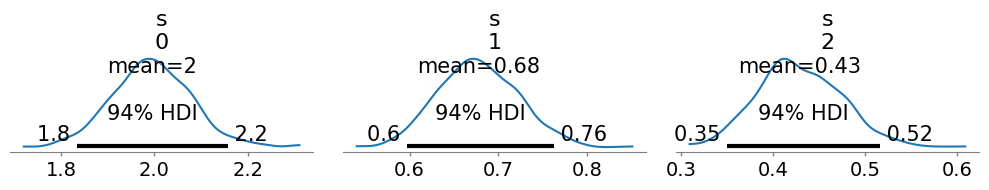

In [12]:
az.plot_posterior(trace, figsize=(10, 2))
plt.tight_layout()
plt.show()

In [10]:
print(az.summary(trace)[["mean", "hdi_3%", "hdi_97%"]].round(2))

       mean  hdi_3%  hdi_97%
b[0]   5.66    5.48     5.84
b[1]   9.37    8.89     9.84
b[2]  19.23   16.98    21.24
